# Task 1 — Exploratory Data Analysis
**Dataset:** MachineLearningRating_v3.txt (~1 million rows, 52 columns)  
**Goal:** Assess data quality and uncover initial patterns in risk and profitability.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.data_loader import load_data, summarize_data, compute_loss_ratio, flag_high_missing
from src.eda_utils import (
    descriptive_stats,
    dtype_review,
    missing_summary_table,
    plot_numeric_distributions,
    plot_categorical_counts,
    loss_ratio_by_group,
    plot_loss_ratio_by_group,
    correlation_heatmap,
    plot_monthly_trend,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Data

In [2]:
df = load_data('../data/MachineLearningRating_v3.txt')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Shape: 1,000,098 rows x 52 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000


## 2. Data Quality — Missing Values

In [3]:
summary = summarize_data(df)
print(f"Duplicate rows      : {summary['duplicate_rows']:,}")
print(f"Columns with nulls  : {sum(v > 0 for v in summary['null_counts'].values())}")

Duplicate rows      : 74
Columns with nulls  : 22


In [4]:
missing_summary_table(df)

,missing_count,missing_pct
WrittenOff,1000098,100.0000
NewVehicle,1000098,100.0000
CrossBorder,1000098,100.0000
NumberOfVehiclesInFleet,1000098,100.0000
Converted,1000098,100.0000
Rebuilt,1000098,100.0000
CustomValueEstimate,779642,77.9600
Bank,145961,14.5900
AccountType,40232,4.0200
Gender,9536,0.9500


In [5]:
high_missing = flag_high_missing(df, threshold=0.5)
print('Columns with >50% missing:', high_missing)

Columns with >50% missing: ['CustomValueEstimate', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']


## 3. Dtype Review — Are Columns Correctly Typed?

In [6]:
dtype_review(df)

,stored_dtype,semantic_type,flag
column,,,
UnderwrittenCoverID,Int64,numerical,
PolicyID,Int64,numerical,
TransactionMonth,datetime64[ns],datetime,
IsVATRegistered,bool,boolean,
Citizenship,object,categorical,
LegalType,object,categorical,
Title,object,categorical,
Language,object,categorical,
Bank,object,categorical,


In [7]:
flagged = dtype_review(df)
flagged = flagged[flagged['flag'] != '']
print(f'{len(flagged)} columns flagged for dtype mismatch:')
flagged

4 columns flagged for dtype mismatch:


,stored_dtype,semantic_type,flag
column,,,
PostalCode,object,categorical,>90% values numeric but stored as object
mmcode,object,categorical,>90% values numeric but stored as object
VehicleIntroDate,object,categorical,may be datetime — consider pd.to_datetime
NumberOfVehiclesInFleet,Int64,numerical,looks boolean — consider casting


## 4. Descriptive Statistics — Numerical Features

In [8]:
descriptive_stats(df)

,UnderwrittenCoverID,PolicyID,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,CapitalOutstanding,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1000098.0000,1000098.0000,1000098.0000,999546.0000,999546.0000,999546.0000,999546.0000,220456.0000,1000096.0000,0.0000,1000098.0000,1000098.0000,1000098.0000,1000098.0000
mean,104817.5461,7956.6825,2010.2254,4.0466,2466.7433,97.2079,4.0192,225531.1299,52678.6071,<NA>,604172.7326,117.8757,61.9055,64.8612
std,63293.7085,5290.0385,3.2614,0.2940,442.8006,19.3933,0.4683,564515.7498,111474.8707,<NA>,1508331.8380,399.7017,230.2845,2384.0747
min,1.0000,14.0000,1987.0000,0.0000,0.0000,0.0000,0.0000,20000.0000,-2.0000,<NA>,0.0100,0.0000,-782.5768,-12002.4123
25%,55143.0000,4500.0000,2008.0000,4.0000,2237.0000,75.0000,4.0000,135000.0000,0.0000,<NA>,5000.0000,3.2248,0.0000,0.0000
50%,94083.0000,7071.0000,2011.0000,4.0000,2694.0000,111.0000,4.0000,220000.0000,0.0000,<NA>,7500.0000,8.4369,2.1783,0.0000
75%,139190.0000,11077.0000,2013.0000,4.0000,2694.0000,111.0000,4.0000,280000.0000,0.0000,<NA>,250000.0000,90.0000,21.9298,0.0000
max,301175.0000,23246.0000,2015.0000,10.0000,12880.0000,309.0000,6.0000,26550000.0000,700000.0000,<NA>,12636200.0000,74422.1679,65282.6034,393092.1053
skewness,0.6117,0.7374,-0.7945,5.7046,3.5760,0.2447,-2.5313,40.8705,2.0125,<NA>,2.5486,122.9746,138.5965,69.9331
kurtosis,0.0288,0.2820,0.6081,71.2853,102.2898,3.0100,18.8338,1762.3216,3.2508,<NA>,4.6452,22210.7017,37176.1855,6791.9262


### Key financial columns close-up

In [9]:
financial_cols = ['TotalPremium', 'TotalClaims', 'SumInsured',
                  'CalculatedPremiumPerTerm', 'CapitalOutstanding']
df[financial_cols].describe().T.assign(
    zeros=(df[financial_cols] == 0).sum(),
    zeros_pct=(df[financial_cols] == 0).mean().mul(100).round(2),
    skewness=df[financial_cols].skew(),
)

,count,mean,std,min,25%,50%,75%,max,zeros,zeros_pct,skewness
TotalPremium,1000098.0000,61.9055,230.2845,-782.5768,0.0000,2.1783,21.9298,65282.6034,381634,38.1600,138.5965
TotalClaims,1000098.0000,64.8612,2384.0747,-12002.4123,0.0000,0.0000,0.0000,393092.1053,997305,99.7200,69.9331
SumInsured,1000098.0000,604172.7326,1508331.8380,0.0100,5000.0000,7500.0000,250000.0000,12636200.0000,0,0.0000,2.5486
CalculatedPremiumPerTerm,1000098.0000,117.8757,399.7017,0.0000,3.2248,8.4369,90.0000,74422.1679,7,0.0000,122.9746
CapitalOutstanding,1000096.0000,52678.6071,111474.8707,-2.0000,0.0000,0.0000,0.0000,700000.0000,792780,79.2700,2.0125


## 5. Univariate Distributions — Numerical

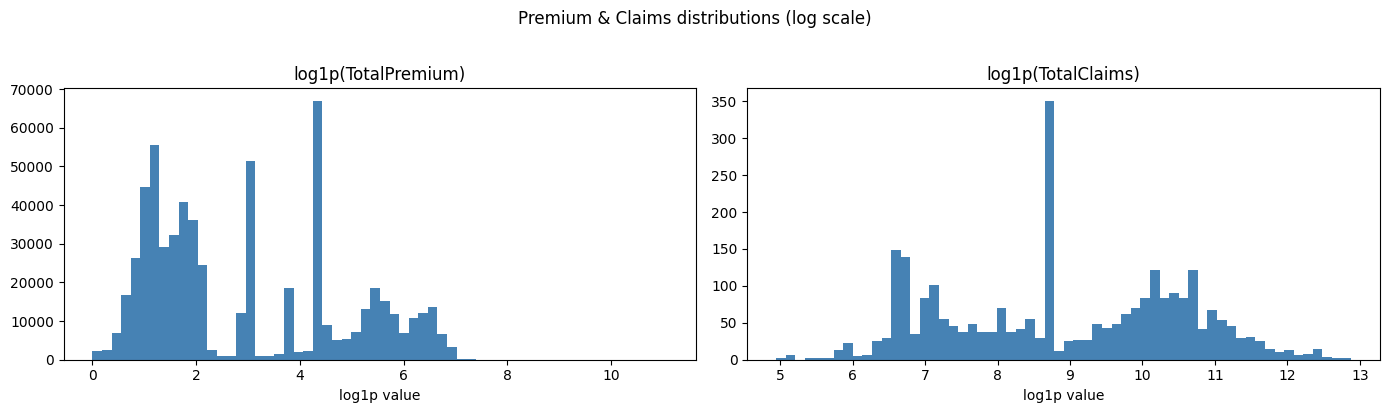

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['TotalPremium', 'TotalClaims']):
    vals = df[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=60, color='steelblue', edgecolor='none')
    ax.set_title(f'log1p({col})')
    ax.set_xlabel('log1p value')
fig.suptitle('Premium & Claims distributions (log scale)', y=1.02)
fig.tight_layout()
plt.show()

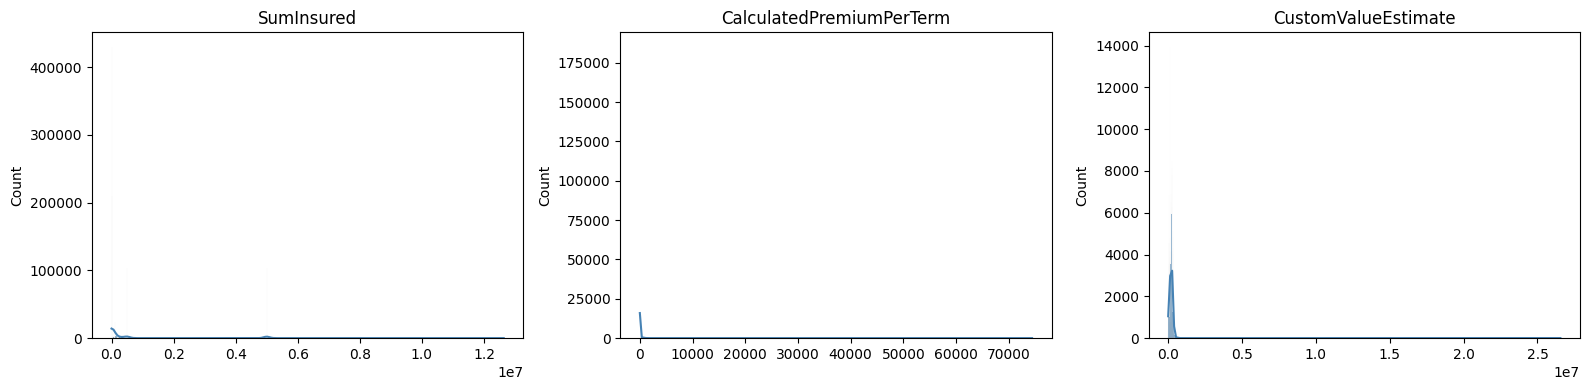

In [11]:
plot_numeric_distributions(df, ['SumInsured', 'CalculatedPremiumPerTerm', 'CustomValueEstimate'])
plt.show()

## 6. Univariate Distributions — Categorical

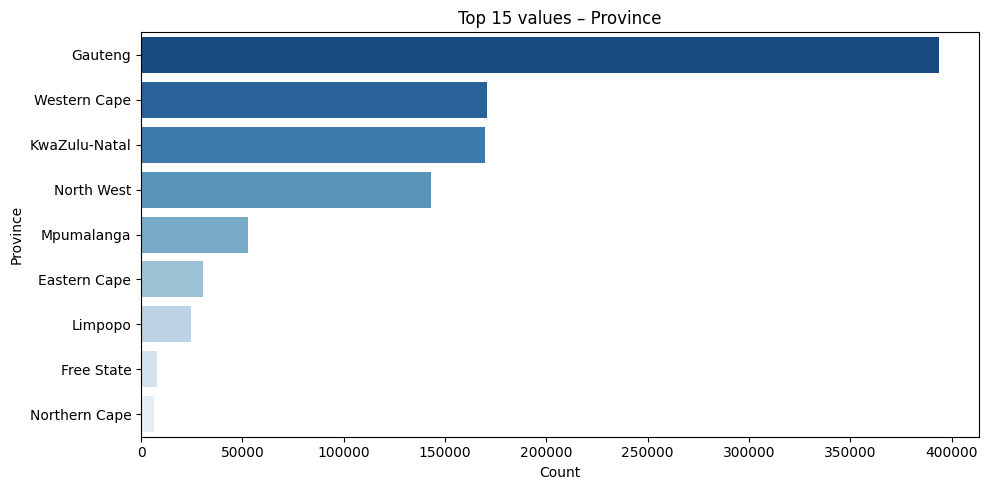

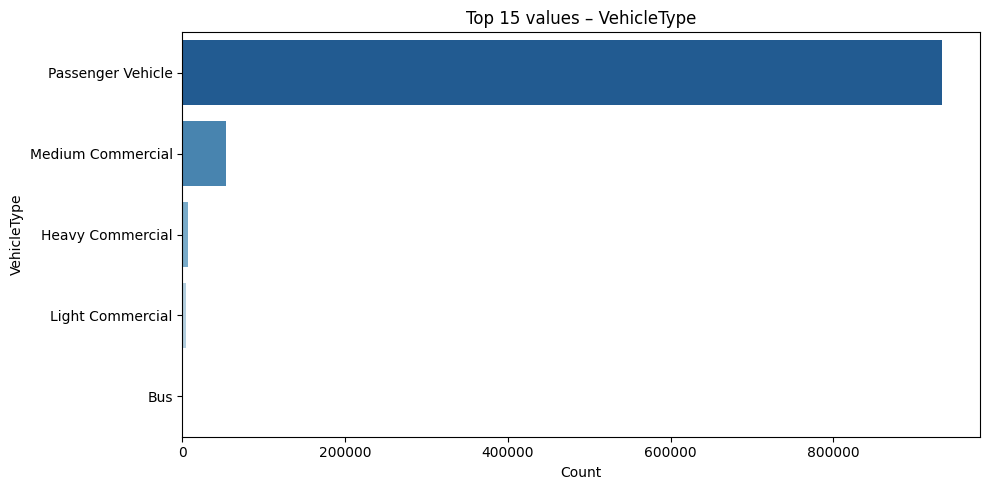

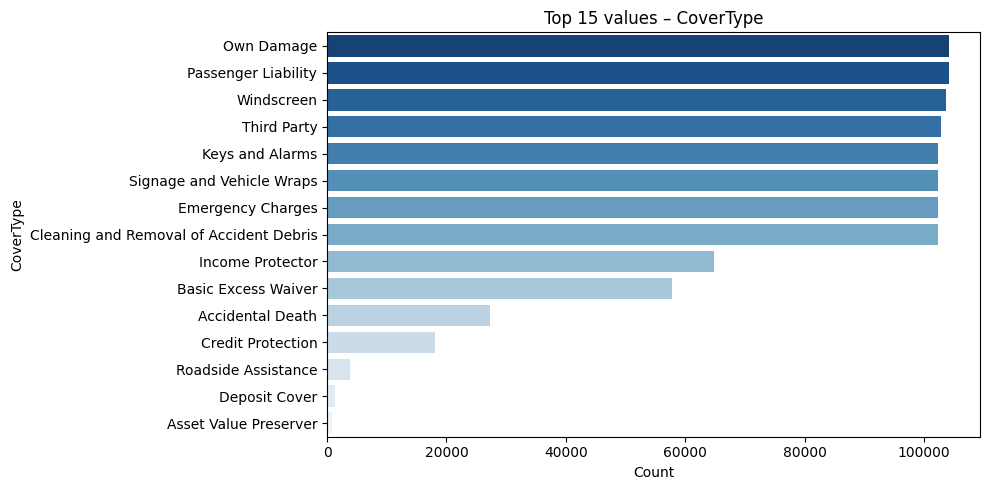

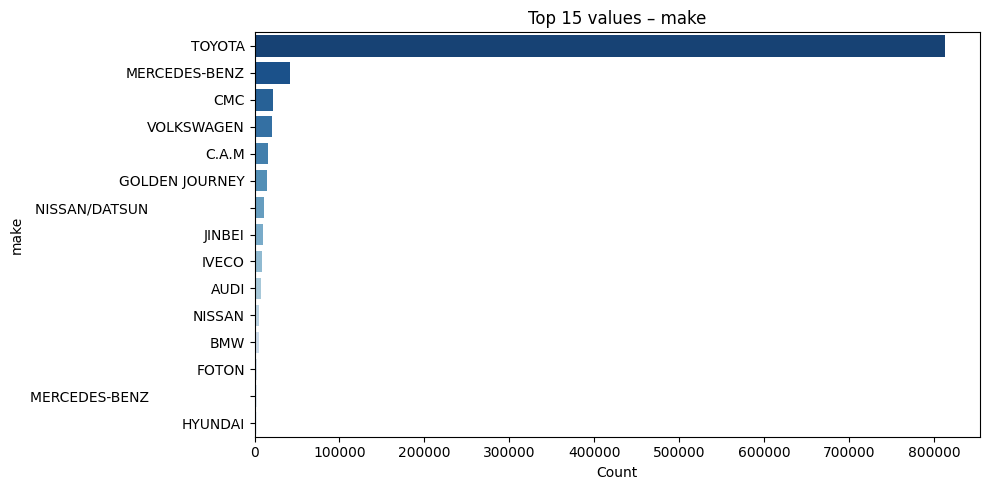

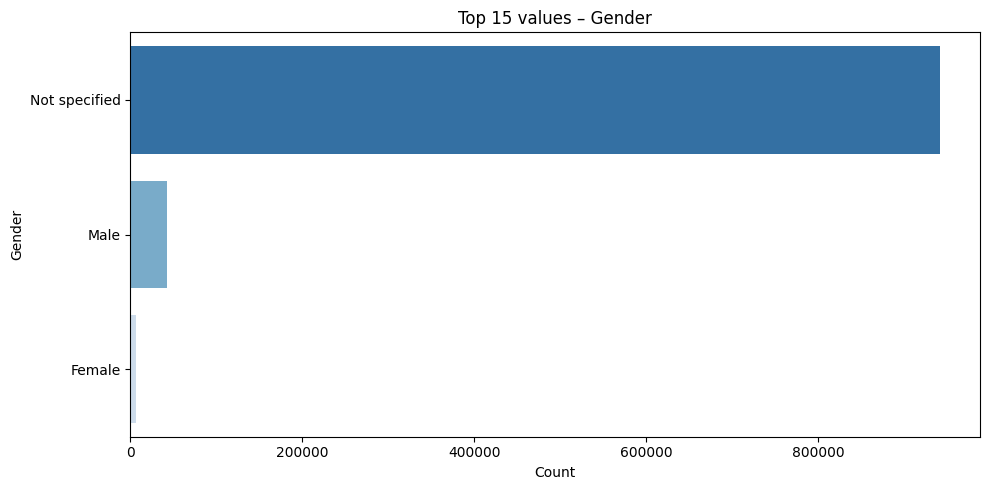

In [12]:
for col in ['Province', 'VehicleType', 'CoverType', 'make', 'Gender']:
    plot_categorical_counts(df, col, top_n=15)
    plt.show()

## 7. Loss Ratio Analysis

In [13]:
df['LossRatio'] = compute_loss_ratio(df)
overall = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f'Overall loss ratio           : {overall:.4f}')
print(f'Unprofitable policies (LR>1) : {(df["LossRatio"] > 1).sum():,}')

Overall loss ratio           : 1.0477
Unprofitable policies (LR>1) : 2,625



--- Loss Ratio by Province ---


,Province,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Gauteng,24053774.5827,29394148.4768,393865,1.2220
1,KwaZulu-Natal,13209079.8122,14301382.4493,169781,1.0827
2,Western Cape,9806558.5289,10389773.7365,170796,1.0595
3,North West,7490508.1785,5920249.9951,143287,0.7904
4,Mpumalanga,2836291.9427,2044675.3579,52718,0.7209
5,Free State,521363.2450,354922.2719,8099,0.6808
6,Limpopo,1537324.4994,1016476.7105,24836,0.6612
7,Eastern Cape,2140103.8334,1356426.6639,30336,0.6338
8,Northern Cape,316558.0737,89490.5088,6380,0.2827


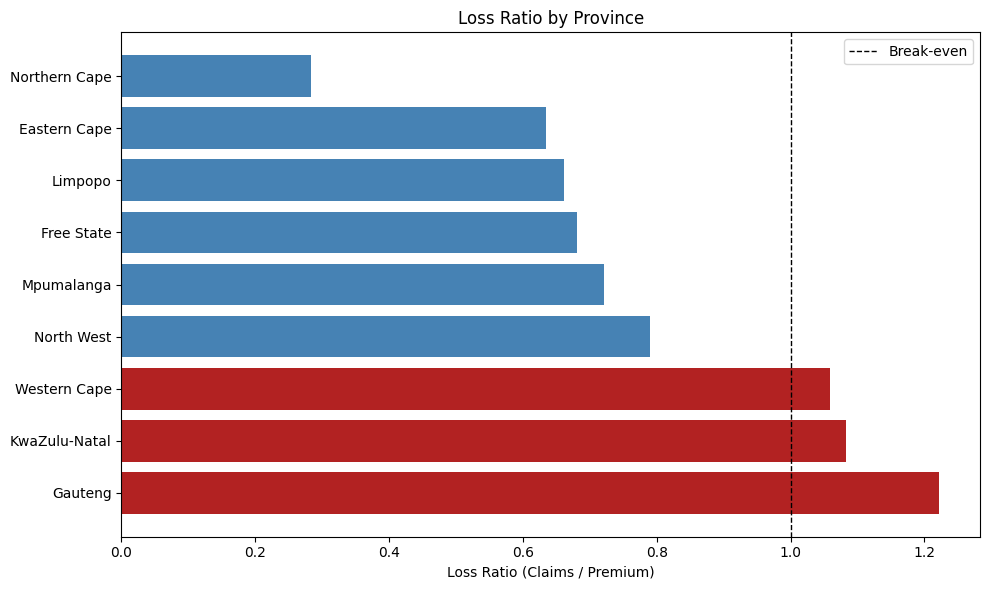


--- Loss Ratio by VehicleType ---


,VehicleType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Heavy Commercial,460947.8629,750474.5833,7401,1.6281
1,Medium Commercial,3922745.5524,4119866.9016,53985,1.0503
2,Passenger Vehicle,56642016.5849,59372069.6758,933598,1.0482
3,Light Commercial,260497.5204,60452.5000,3897,0.2321
4,Bus,58244.7397,7996.5351,665,0.1373


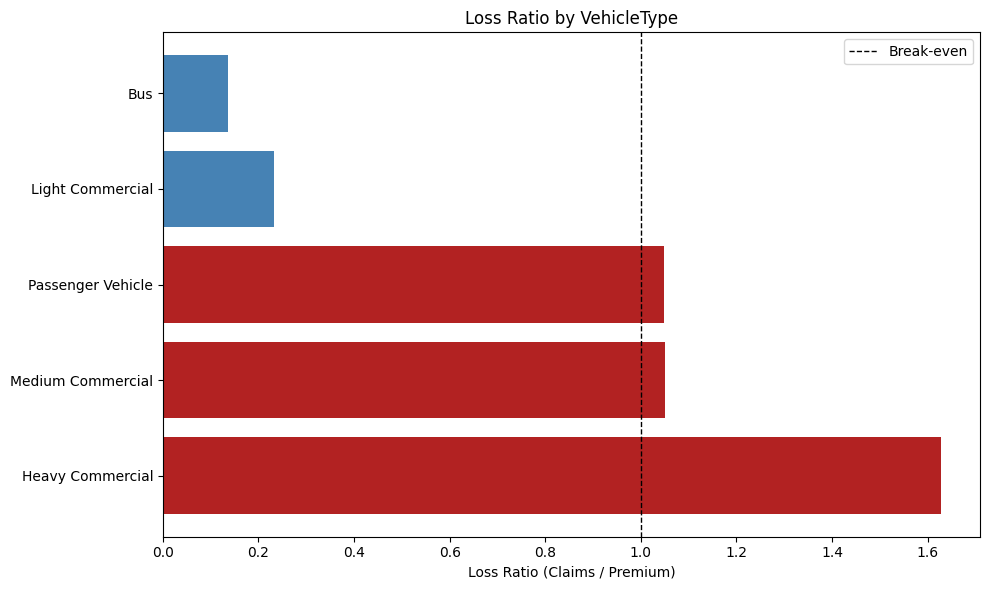


--- Loss Ratio by CoverType ---


,CoverType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Factory Fitted Sound and Other Electronic Equi...,0.0000,21094.7368,3,inf
1,Own Damage,37396054.5399,59009447.6919,104183,1.5780
2,Windscreen,1288698.8608,1285766.0632,103763,0.9977
3,Income Protector,2973254.1145,2565458.7719,64813,0.8628
4,Deposit Cover,66835.3038,43859.6491,1299,0.6562
5,Credit Protection,1846776.4695,332589.3772,18070,0.1801
6,Third Party,13387268.5373,1582009.6140,102825,0.1182
7,Roadside Assistance,34485.8913,3344.0965,3834,0.0970
8,Emergency Charges,321486.7723,16410.3167,102416,0.0510
9,Keys and Alarms,214324.7278,7565.8533,102428,0.0353


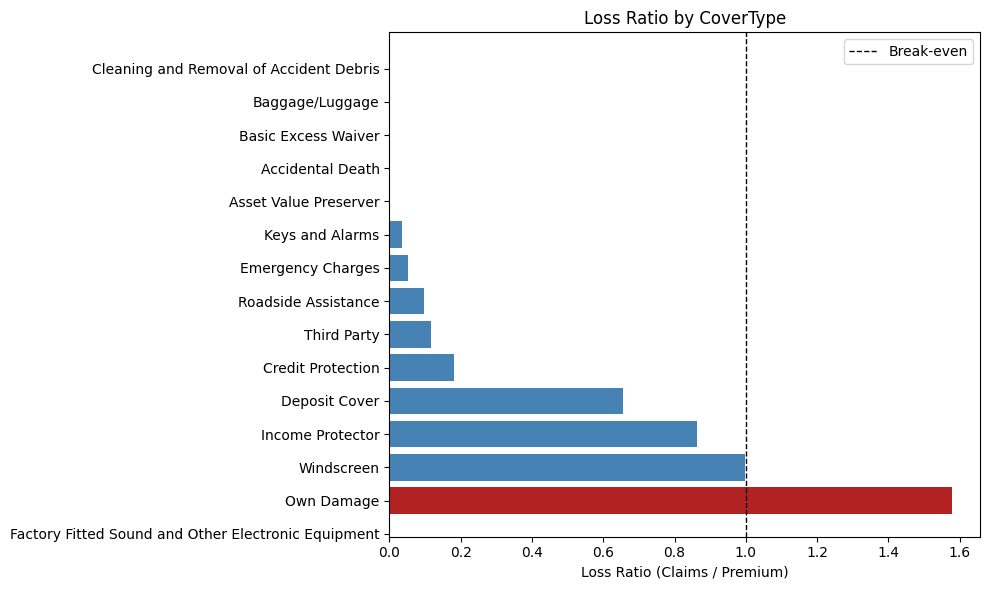


--- Loss Ratio by make ---


,make,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,SUZUKI,27012.5675,171210.8947,408,6.3382
1,JMC,5635.7863,23002.1754,120,4.0814
2,HYUNDAI,113615.5560,453307.9386,2602,3.9898
3,POLARSUN,41029.4020,125197.8433,934,3.0514
4,MARCOPOLO,2665.6514,7996.5351,51,2.9998
5,AUDI,376274.3198,1021003.7126,7407,2.7135
6,BMW,242765.2435,481497.1504,5317,1.9834
7,B.A.W,166044.0147,287137.4737,2160,1.7293
8,IVECO,526126.2385,755892.9518,8430,1.4367
9,CMC,957445.9996,1323615.5319,21624,1.3824


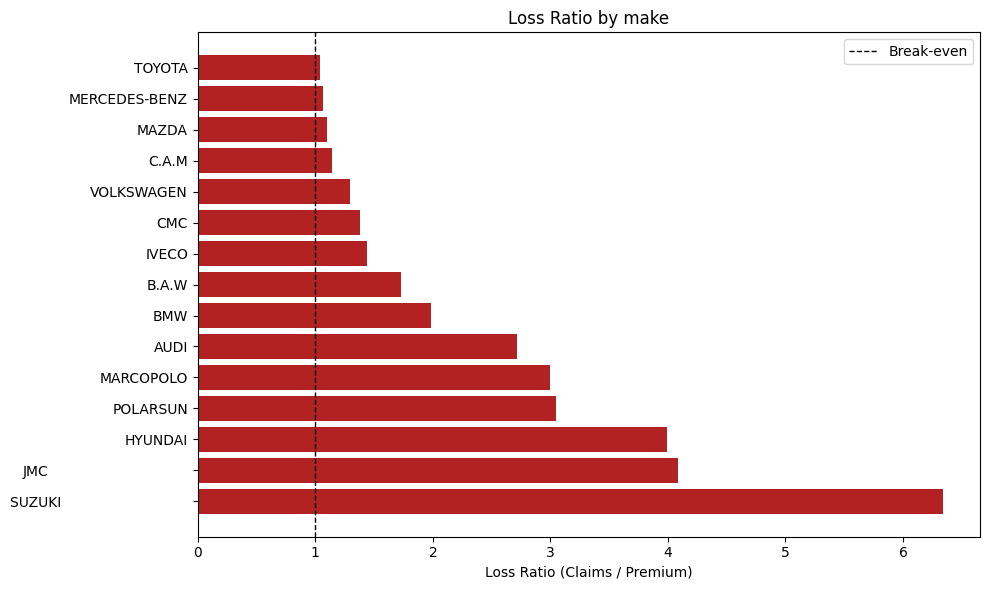

In [14]:
for dim in ['Province', 'VehicleType', 'CoverType', 'make']:
    print(f'\n--- Loss Ratio by {dim} ---')
    display(loss_ratio_by_group(df, dim).head(10))
    plot_loss_ratio_by_group(df, dim, top_n=15)
    plt.show()

## 8. Correlation Matrix

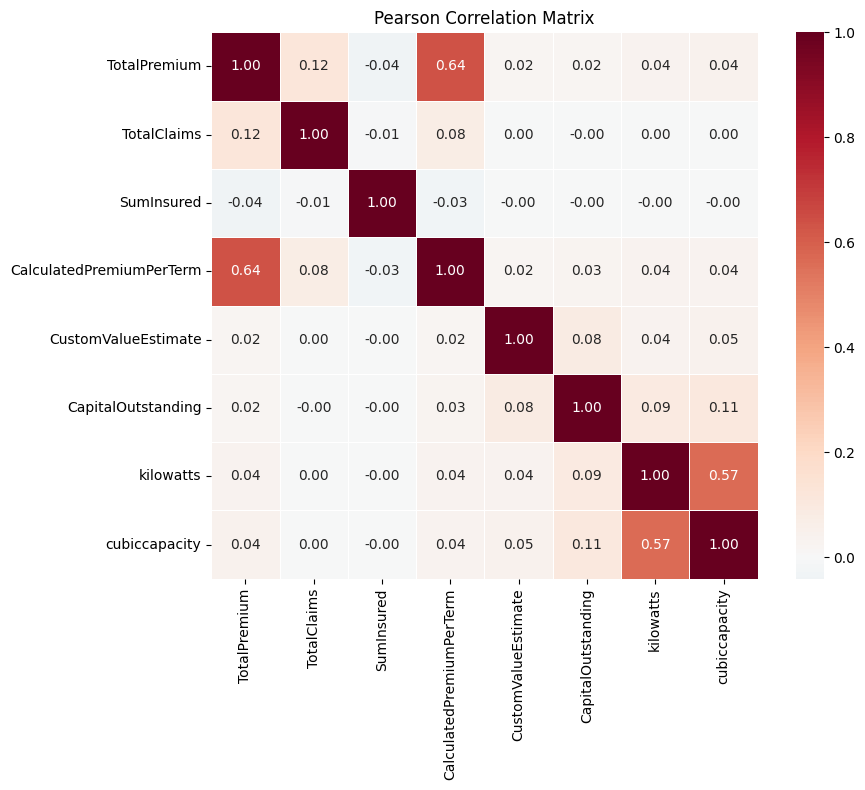

In [15]:
num_cols = ['TotalPremium', 'TotalClaims', 'SumInsured',
            'CalculatedPremiumPerTerm', 'CustomValueEstimate',
            'CapitalOutstanding', 'kilowatts', 'cubiccapacity']
correlation_heatmap(df, num_cols)
plt.show()

## 9. Temporal Trends

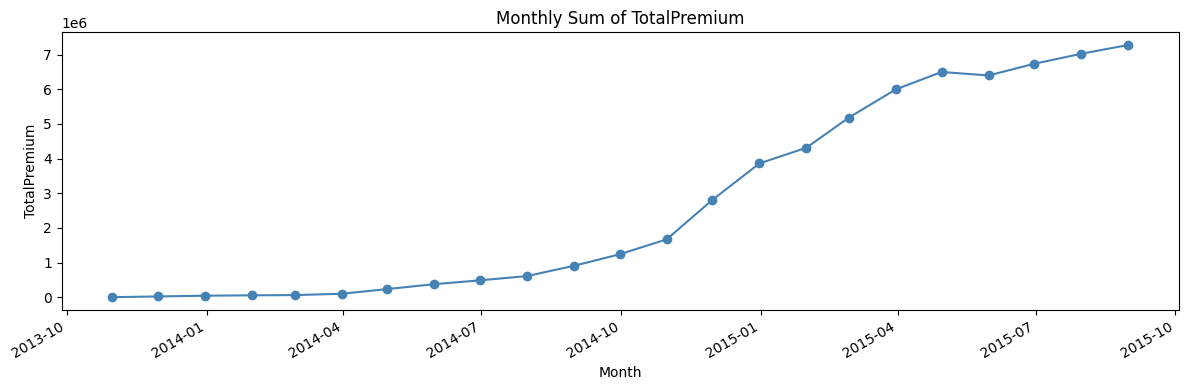

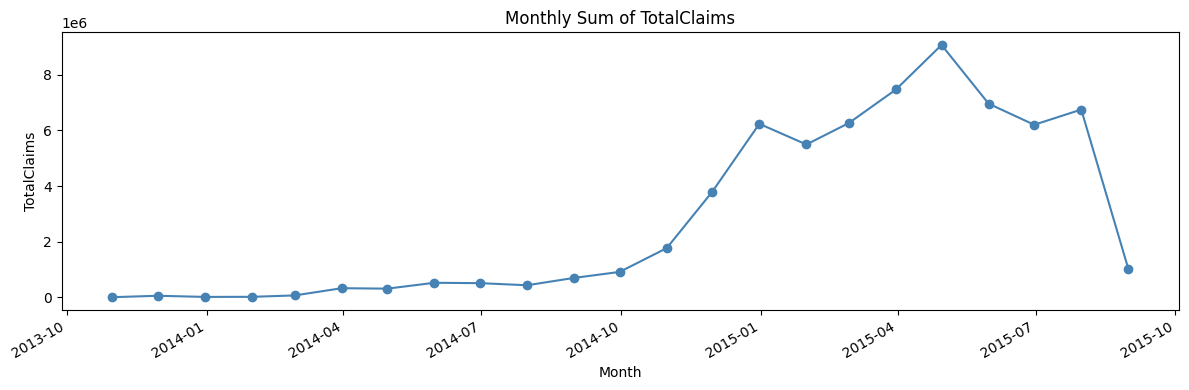

In [16]:
for col in ['TotalPremium', 'TotalClaims']:
    plot_monthly_trend(df, col, agg='sum')
    plt.show()

## 10. Key Findings Summary

| Finding | Detail |
|---|---|
| **Zero-inflated claims** | 99.7% of rows have TotalClaims = 0 |
| **Zero premiums** | 38.2% of rows have TotalPremium = 0 — needs investigation |
| **High-missing columns** | CrossBorder (100%), NumberOfVehiclesInFleet (100%), WrittenOff/Rebuilt/Converted (~70%) |
| **Dtype mismatches** | PostalCode & mmcode numeric but stored as object; VehicleIntroDate is a date string |
| **Extreme skewness** | TotalPremium skew ~139, TotalClaims skew ~70 — log transform needed for modelling |